# Parte 3 – Cruce por ubigeo y análisis
**Grupo 7 · Temporada: 1 de enero – 31 de mayo de 2024**

Pregunta: **¿El Estado declara emergencia donde más llueve?**

In [1]:
import os
import pandas as pd
import plotly.express as px
from IPython.display import Image, display

## 1. Crear `datos/ubigeos.csv`
Ubigeos departamentales oficiales del INEI.

In [2]:
ubigeos = pd.DataFrame({
    "ubigeo": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10",
               "11", "12", "13", "14", "15", "16", "17", "18", "19", "20",
               "21", "22", "23", "24", "25"],
    "departamento": ["Amazonas", "Áncash", "Apurímac", "Arequipa", "Ayacucho",
                     "Cajamarca", "Callao", "Cusco", "Huancavelica", "Huánuco",
                     "Ica", "Junín", "La Libertad", "Lambayeque", "Lima",
                     "Loreto", "Madre de Dios", "Moquegua", "Pasco", "Piura",
                     "Puno", "San Martín", "Tacna", "Tumbes", "Ucayali"]
})
ubigeos.to_csv("datos/ubigeos.csv", index=False, encoding="utf-8-sig")
print("Filas:", len(ubigeos))

Filas: 25


## 2. Lectura normal vs. lectura como texto

In [3]:
ubigeos_numero = pd.read_csv("datos/ubigeos.csv")
ubigeos_texto = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})

pd.DataFrame({
    "departamento": ubigeos_texto["departamento"],
    "lectura_normal": ubigeos_numero["ubigeo"],
    "como_texto": ubigeos_texto["ubigeo"],
}).head(10)

,departamento,lectura_normal,como_texto
0,Amazonas,1,01
1,Áncash,2,02
2,Apurímac,3,03
3,Arequipa,4,04
4,Ayacucho,5,05
5,Cajamarca,6,06
6,Callao,7,07
7,Cusco,8,08
8,Huancavelica,9,09
9,Huánuco,10,10


**¿Por qué importa?** La lectura normal convierte el ubigeo en número y elimina el cero inicial (`01` → `1`). El ubigeo es un **código**, no una cantidad: sin el cero ya no coincide con el formato oficial ni con otras tablas que lo tienen como texto, y el cruce falla. Por eso se lee siempre con `dtype={"ubigeo": str}`.

In [4]:
ubigeos = ubigeos_texto.copy()

## 3. Agregar el ubigeo a las tablas de decretos y lluvias

In [5]:
decretos = pd.read_csv("datos/decretos_por_departamento.csv")
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv")

decretos = decretos.merge(ubigeos, on="departamento", how="left")
lluvias = lluvias.merge(ubigeos, on="departamento", how="left")

print("Decretos:", decretos.shape, "| Lluvias:", lluvias.shape)

Decretos: (24, 4) | Lluvias: (25, 7)


## 4. Verificación: departamentos sin ubigeo

In [6]:
print("Sin ubigeo en decretos:", decretos[decretos["ubigeo"].isna()]["departamento"].tolist())
print("Sin ubigeo en lluvias: ", lluvias[lluvias["ubigeo"].isna()]["departamento"].tolist())

Sin ubigeo en decretos: []
Sin ubigeo en lluvias:  []


Ningún departamento quedó sin ubigeo: las Partes 1 y 2 guardaron los nombres con las mismas tildes que la tabla del INEI. La tabla de decretos tiene 24 filas porque el **Callao no tuvo decretos** en 2024; se recupera en el cruce.

## 5. Cruce por `ubigeo`
Se parte de la tabla de lluvias (25 departamentos) con `how="left"` para que ninguno desaparezca.

In [7]:
tabla_final = lluvias.merge(
    decretos[["ubigeo", "declaratorias", "prorrogas"]],
    on="ubigeo",
    how="left"
)
tabla_final[["declaratorias", "prorrogas"]] = tabla_final[["declaratorias", "prorrogas"]].fillna(0).astype(int)
tabla_final["lluvia_total_mm"] = tabla_final["lluvia_total_mm"].round(1)

tabla_final = tabla_final[["ubigeo", "departamento", "capital", "latitud", "longitud",
                           "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]]
tabla_final = tabla_final.sort_values("ubigeo").reset_index(drop=True)
tabla_final

,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,455.0,0,4,2
1,02,Áncash,Huaraz,-9.52614,-77.52869,1058.3,3,4,5
2,03,Apurímac,Abancay,-13.63426,-72.88380,670.6,2,7,4
3,04,Arequipa,Arequipa,-16.39899,-71.53747,235.3,1,7,6
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,467.5,1,7,5
5,06,Cajamarca,Cajamarca,-7.16378,-78.50027,671.2,0,3,3
6,07,Callao,Callao,-12.05162,-77.13452,17.3,0,0,0
7,08,Cusco,Cusco,-13.53188,-71.96701,601.0,0,7,5
8,09,Huancavelica,Huancavelica,-12.78691,-74.97298,819.2,1,7,4
9,10,Huánuco,Huánuco,-9.92882,-76.23989,416.7,3,6,3


## 6. Verificación: 25 filas y ceros

In [8]:
print("Filas:", len(tabla_final))
print("Departamentos con 0 declaratorias:")
tabla_final[tabla_final["declaratorias"] == 0][["ubigeo", "departamento", "declaratorias", "prorrogas"]]

Filas: 25
Departamentos con 0 declaratorias:


,ubigeo,departamento,declaratorias,prorrogas
6,07,Callao,0,0
13,14,Lambayeque,0,2
19,20,Piura,0,2
23,24,Tumbes,0,2


## 7. Guardar `datos/tabla_final.csv`

In [9]:
tabla_final.to_csv("datos/tabla_final.csv", index=False, encoding="utf-8-sig")

comprobacion = pd.read_csv("datos/tabla_final.csv", dtype={"ubigeo": str})
print("Ubigeos de 2 dígitos:", (comprobacion["ubigeo"].str.len() == 2).all())
print(comprobacion["ubigeo"].head(3).tolist())

Ubigeos de 2 dígitos: True
['01', '02', '03']


## 8. Gráficos

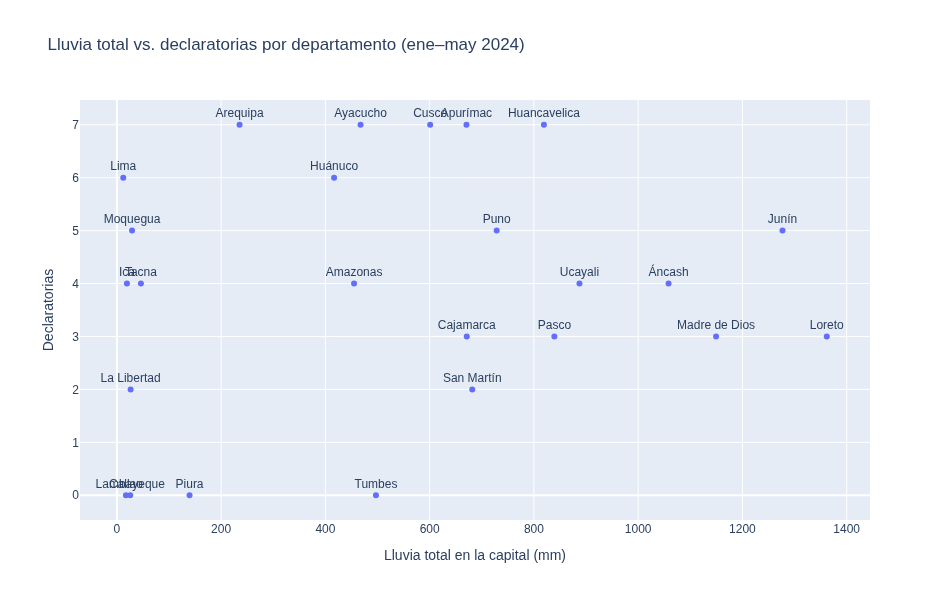

In [10]:
fig_disp = px.scatter(
    tabla_final, x="lluvia_total_mm", y="declaratorias", text="departamento",
    title="Lluvia total vs. declaratorias por departamento (ene–may 2024)",
    labels={"lluvia_total_mm": "Lluvia total en la capital (mm)", "declaratorias": "Declaratorias"},
)
fig_disp.update_traces(textposition="top center")
fig_disp.update_layout(width=950, height=600)
fig_disp.show()

os.makedirs("graficos", exist_ok=True)
fig_disp.write_image("graficos/dispersion.png")
display(Image("graficos/dispersion.png"))

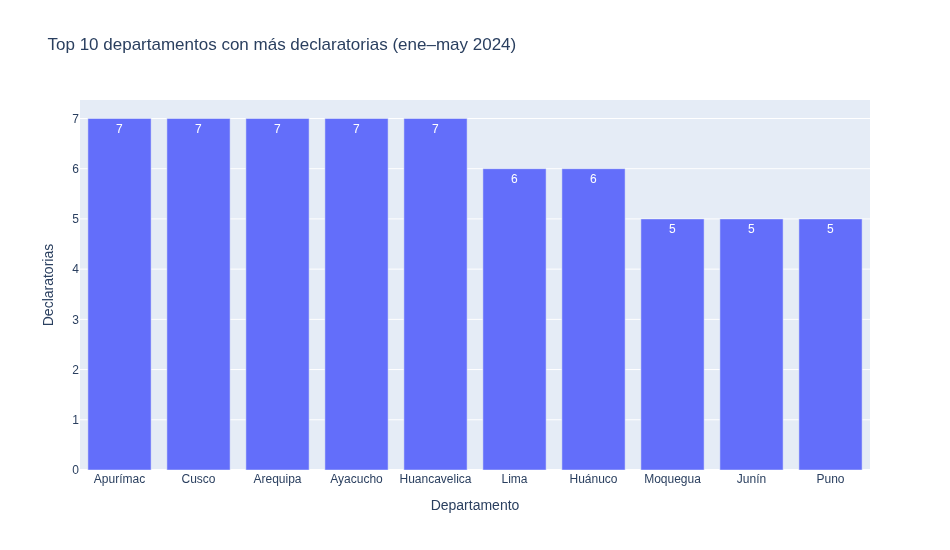

In [11]:
top10 = tabla_final.sort_values("declaratorias", ascending=False).head(10)

fig_barras = px.bar(
    top10, x="departamento", y="declaratorias", text="declaratorias",
    title="Top 10 departamentos con más declaratorias (ene–may 2024)",
    labels={"departamento": "Departamento", "declaratorias": "Declaratorias"},
)
fig_barras.update_layout(width=950, height=550)
fig_barras.show()

fig_barras.write_image("graficos/top10.png")
display(Image("graficos/top10.png"))

## 9. Respuestas

In [12]:
print("Más declaratorias:")
print(tabla_final.sort_values(["declaratorias", "lluvia_total_mm"], ascending=False)
      [["departamento", "declaratorias", "lluvia_total_mm"]].head(5).to_string(index=False))
print("\nMás lluvia:")
print(tabla_final.sort_values("lluvia_total_mm", ascending=False)
      [["departamento", "lluvia_total_mm", "declaratorias"]].head(3).to_string(index=False))
print("\nCorrelación lluvia–declaratorias:",
      round(tabla_final["lluvia_total_mm"].corr(tabla_final["declaratorias"]), 2))

Más declaratorias:
departamento  declaratorias  lluvia_total_mm
Huancavelica              7            819.2
    Apurímac              7            670.6
       Cusco              7            601.0
    Ayacucho              7            467.5
    Arequipa              7            235.3

Más lluvia:
 departamento  lluvia_total_mm  declaratorias
       Loreto           1361.8              3
        Junín           1276.9              5
Madre de Dios           1149.5              3

Correlación lluvia–declaratorias: 0.17


In [13]:
decretos_lluvias = pd.read_csv("datos/decretos_lluvias.csv")
print(pd.crosstab(decretos_lluvias["tipo"], decretos_lluvias["motivo"], margins=True))

declaratorias = decretos_lluvias[decretos_lluvias["tipo"] == "declara"]
print("\n% de declaratorias por motivo:")
print((declaratorias["motivo"].value_counts(normalize=True) * 100).round(1))

motivo    impacto de daños  peligro inminente  All
tipo                                              
declara                 10                  0   10
prorroga                 8                  2   10
All                     18                  2   20

% de declaratorias por motivo:
motivo
impacto de daños    100.0
Name: proportion, dtype: float64


**1. Top 3 en declaratorias y en lluvia.** Cinco departamentos empatan con 7 declaratorias; desempatando por lluvia, el top 3 es **Huancavelica, Apurímac y Cusco**. Donde más llovió fue en **Loreto, Junín y Madre de Dios** (3, 5 y 3 declaratorias). **No coinciden.**

**2. Casos opuestos.** Mucha lluvia y pocas declaratorias: Loreto (1362 mm, 3), Madre de Dios (1150 mm, 3) y Tumbes (497 mm, 0). Poca lluvia y muchas declaratorias: Lima (12 mm, 6), Moquegua (29 mm, 5) y Arequipa (235 mm, 7). Razones:
- La lluvia se mide en la capital (costera en Lima, Moquegua y Arequipa), pero las emergencias ocurren en distritos de sierra.
- El daño depende de la vulnerabilidad del territorio: en la Amazonía la lluvia intensa es normal; en la sierra provoca huaicos.
- Varias emergencias venían de 2023 (El Niño) y se manejaron como prórrogas, no como declaratorias nuevas (Piura, Tumbes, Lambayeque).

**3. Motivo.** El **100 %** de las 10 declaratorias fue por **impacto de daños** y el **0 %** por peligro inminente. La gestión del riesgo en 2024 fue **reactiva**: se declaró emergencia después del daño, no antes.

**4. Limitaciones.**
- Una sola estación (la capital) no representa la lluvia de todo el departamento.
- Se cuentan decretos, no distritos ni población afectada.
- Normas cuyo título no menciona lluvias quedaron fuera, y "Ancash" sin tilde (DS 0012-2024-PCM) no se contó para Áncash.
- Open-Meteo da estimaciones de modelo, no mediciones del SENAMHI.
- Es una sola temporada; la correlación no implica causalidad.

**5. Conclusión.** En la temporada 2024 el Estado **no** declaró más emergencias donde más llovió: la correlación entre lluvia y declaratorias es muy débil (0.17). Los departamentos más lluviosos (Loreto, Junín, Madre de Dios) tuvieron pocas declaratorias, mientras que estas se concentraron en la sierra sur y centro (Huancavelica, Apurímac, Cusco, Ayacucho, Arequipa). Todas fueron por impacto de daños. Las emergencias siguen al **daño y la vulnerabilidad**, no a la cantidad de lluvia, con la limitación de que la lluvia se midió solo en las capitales.